In [130]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

import glob
from pathlib import Path

import numpy as np
import pandas as pd

from aicsimageio import AICSImage, readers

from tqdm import tqdm

from matplotlib import pyplot as plt
import seaborn as sns

In [131]:
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["svg.fonttype"] = "none"

## load layouts from file

In [132]:
Experiment1Layout = pd.read_csv('260119_CytoplasmicPOLR2A/METADATA/260119_CytoplasmicPOLR2A.csv')
Experiment2Layout = pd.read_csv('260306_CytoplasmicPOLR2A/METADATA/260306_CytoplasmicPOLR2A.csv')

## load quantification files and assemble into dataframes

In [133]:
Experiment1_Quantification_Directory = Path("/Users/alexandergillis/Desktop/KATANA_PULL/260119_CytoplasmicPOLR2A/40x/20260128_175303_338/QUANTIFICATION/")
Experiment1_Quantification_Files = glob.glob(str(Experiment1_Quantification_Directory / "*.csv"))

Experiment2_Quantification_Directory = Path("/Users/alexandergillis/Desktop/KATANA_PULL/260306_CytoplasmicPOLR2A/20260310_190059_521/QUANTIFICATION/")
Experiment2_Quantification_Files = glob.glob(str(Experiment2_Quantification_Directory / "*.csv"))

len(Experiment1_Quantification_Files), len(Experiment2_Quantification_Files)

(1539, 2160)

### experiment 1

In [134]:
Experiment1_Quantification_Files_Nucleus = [i for i in Experiment1_Quantification_Files if "nuclei_" in i]
Experiment1_Quantification_Files_Cytoplasm = [i for i in Experiment1_Quantification_Files if "cyto_" in i]
Experiment1_Quantification_Files_Cell = [i for i in Experiment1_Quantification_Files if "cells_" in i]

In [135]:
qdfs = list()


for f in tqdm(Experiment1_Quantification_Files_Cell):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_1['file'].tolist()


wellnames = [f[10:13] for f in files]
quantifcation_percell_1['well'] = wellnames

fovs = [f[48:52] for f in files]
quantifcation_percell_1['fov'] = fovs

100%|████████████████████████████████████████| 513/513 [00:01<00:00, 263.95it/s]


In [136]:
qdfs = list()


for f in tqdm(Experiment1_Quantification_Files_Nucleus):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_pernuc_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_pernuc_1['file'].tolist()


wellnames = [f[11:14] for f in files]
quantifcation_pernuc_1['well'] = wellnames

fovs = [f[49:53] for f in files]
quantifcation_pernuc_1['fov'] = fovs

100%|████████████████████████████████████████| 513/513 [00:01<00:00, 274.00it/s]


In [137]:
qdfs = list()


for f in tqdm(Experiment1_Quantification_Files_Cytoplasm):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percyto_1 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percyto_1['file'].tolist()


wellnames = [f[9:12] for f in files]
quantifcation_percyto_1['well'] = wellnames

fovs = [f[47:51] for f in files]
quantifcation_percyto_1['fov'] = fovs

100%|████████████████████████████████████████| 513/513 [00:01<00:00, 268.56it/s]


In [138]:
# exclude border cells
quantifcation_percell_1 = quantifcation_percell_1.query('Cells_is_border == False')

In [139]:
Intensities1 = pd.DataFrame({
    "WELL" : quantifcation_percell_1['well'],
    "FOV" : quantifcation_percell_1['fov'],
    "LABEL" : quantifcation_percell_1['label'],
    "CELL_IF_647_Intensity" : quantifcation_percell_1['Cells_intensity_mean_640_0'],
    "CELL_IF_561_Intensity" : quantifcation_percell_1['Cells_intensity_mean_561_2'],
    "CellArea" : quantifcation_percell_1['Cells_area']
})

In [140]:
IntensitiesPerNuclei1 = pd.DataFrame({
    "WELL" : quantifcation_pernuc_1['well'],
    "FOV" : quantifcation_pernuc_1['fov'],
    "LABEL" : quantifcation_pernuc_1['label'],
    "NUCLEUS_IF_647_Intensity" : quantifcation_pernuc_1['Nuclei_intensity_mean_640_0'],
    "NUCLEUS_IF_561_Intensity" : quantifcation_pernuc_1['Nuclei_intensity_mean_561_2'],
    "Nucleus_DAPI_Intensity" : quantifcation_pernuc_1['Nuclei_intensity_mean_405_5'],
    "NucleusArea" : quantifcation_pernuc_1['Nuclei_area']
})

In [141]:
IntensitiesPerCyto1 = pd.DataFrame({
    "WELL" : quantifcation_percyto_1['well'],
    "FOV" : quantifcation_percyto_1['fov'],
    "LABEL" : quantifcation_percyto_1['label'],
    "CYTOPLASM_IF_647_Intensity" : quantifcation_percyto_1['Cytoplasm_intensity_mean_640_0'],
    "CYTOPLASM_IF_561_Intensity" : quantifcation_percyto_1['Cytoplasm_intensity_mean_561_2'],
    "CytoplasmArea" : quantifcation_percyto_1['Cytoplasm_area']
})

In [142]:
# merge nucleus and cytoplasm data into whole cell
Intensities1 = Intensities1.merge(IntensitiesPerNuclei1, how = 'left', left_on = ["WELL", "FOV", "LABEL"], right_on = ["WELL", "FOV", "LABEL"])
Intensities1 = Intensities1.merge(IntensitiesPerCyto1, how = 'left', left_on = ["WELL", "FOV", "LABEL"], right_on = ["WELL", "FOV", "LABEL"])

In [143]:
## exclude cells with missing segmentation
Intensities1.dropna(inplace = True)

In [144]:
## filter for cells with some segmented nuclei of minimum size
Intensities1 = Intensities1.query('NucleusArea > 500')

In [145]:
CountsByWell1 = Intensities1.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell1.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)

In [146]:
IntensitiesByWell1 = Intensities1.drop(['FOV','LABEL'], axis = 1).groupby('WELL').mean().reset_index().merge(Experiment1Layout, how = 'left')
IntensitiesByWell1 = IntensitiesByWell1.merge(CountsByWell1, how = 'left')

### experiment 2

In [147]:
Experiment2_Quantification_Files_Nucleus = [i for i in Experiment2_Quantification_Files if "nuclei_" in i]
Experiment2_Quantification_Files_Cytoplasm = [i for i in Experiment2_Quantification_Files if "cyto_" in i]
Experiment2_Quantification_Files_Cell = [i for i in Experiment2_Quantification_Files if "cells_" in i]

In [148]:
qdfs = list()


for f in tqdm(Experiment2_Quantification_Files_Cell):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percell_2 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percell_2['file'].tolist()


wellnames = [f[10:13] for f in files]
quantifcation_percell_2['well'] = wellnames

fovs = [f[48:52] for f in files]
quantifcation_percell_2['fov'] = fovs

100%|████████████████████████████████████████| 720/720 [00:03<00:00, 209.08it/s]


In [149]:
qdfs = list()


for f in tqdm(Experiment2_Quantification_Files_Nucleus):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_pernuc_2 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_pernuc_2['file'].tolist()


wellnames = [f[11:14] for f in files]
quantifcation_pernuc_2['well'] = wellnames

fovs = [f[49:53] for f in files]
quantifcation_pernuc_2['fov'] = fovs

100%|████████████████████████████████████████| 720/720 [00:03<00:00, 219.44it/s]


In [150]:
qdfs = list()


for f in tqdm(Experiment2_Quantification_Files_Cytoplasm):
    data = pd.read_csv(f)
    data['file'] = Path(f).stem
    qdfs.append(data)

quantifcation_percyto_2 = pd.concat(qdfs, ignore_index=True)

files = quantifcation_percyto_2['file'].tolist()


wellnames = [f[9:12] for f in files]
quantifcation_percyto_2['well'] = wellnames

fovs = [f[47:51] for f in files]
quantifcation_percyto_2['fov'] = fovs

100%|████████████████████████████████████████| 720/720 [00:03<00:00, 218.06it/s]


In [151]:
# exclude border cells
quantifcation_percell_2 = quantifcation_percell_2.query('Cells_is_border == False')

In [152]:
Intensities2 = pd.DataFrame({
    "WELL" : quantifcation_percell_2['well'],
    "FOV" : quantifcation_percell_2['fov'],
    "LABEL" : quantifcation_percell_2['label'],
    "CELL_IF_647_Intensity" : quantifcation_percell_2['Cells_intensity_mean_647_0'],
    "CELL_IF_561_Intensity" : quantifcation_percell_2['Cells_intensity_mean_561_2'],
    "CellArea" : quantifcation_percell_2['Cells_area']
})

In [153]:
IntensitiesPerNuclei2 = pd.DataFrame({
    "WELL" : quantifcation_pernuc_2['well'],
    "FOV" : quantifcation_pernuc_2['fov'],
    "LABEL" : quantifcation_pernuc_2['label'],
    "NUCLEUS_IF_647_Intensity" : quantifcation_pernuc_2['Nuclei_intensity_mean_647_0'],
    "NUCLEUS_IF_561_Intensity" : quantifcation_pernuc_2['Nuclei_intensity_mean_561_2'],
    "Nucleus_DAPI_Intensity" : quantifcation_pernuc_2['Nuclei_intensity_mean_405_5'],
    "NucleusArea" : quantifcation_pernuc_2['Nuclei_area']
})

In [154]:
IntensitiesPerCyto2 = pd.DataFrame({
    "WELL" : quantifcation_percyto_2['well'],
    "FOV" : quantifcation_percyto_2['fov'],
    "LABEL" : quantifcation_percyto_2['label'],
    "CYTOPLASM_IF_647_Intensity" : quantifcation_percyto_2['Cytoplasm_intensity_mean_647_0'],
    "CYTOPLASM_IF_561_Intensity" : quantifcation_percyto_2['Cytoplasm_intensity_mean_561_2'],
    "CytoplasmArea" : quantifcation_percyto_2['Cytoplasm_area']
})

In [155]:
# merge nucleus and cytoplasm data into whole cell
Intensities2 = Intensities2.merge(IntensitiesPerNuclei2, how = 'left', left_on = ["WELL", "FOV", "LABEL"], right_on = ["WELL", "FOV", "LABEL"])
Intensities2 = Intensities2.merge(IntensitiesPerCyto2, how = 'left', left_on = ["WELL", "FOV", "LABEL"], right_on = ["WELL", "FOV", "LABEL"])

In [156]:
## exclude cells with missing segmentation
Intensities2.dropna(inplace = True)

In [157]:
## filter for cells with some segmented nuclei of minimum size
Intensities2 = Intensities2.query('NucleusArea > 500')

In [158]:
CountsByWell2 = Intensities2.groupby('WELL').count()['NucleusArea'].reset_index()
CountsByWell2.rename(columns = {'NucleusArea' : 'TotalNumberCells'}, inplace=True)

In [159]:
IntensitiesByWell2 = Intensities2.drop(['FOV','LABEL'], axis = 1).groupby('WELL').mean().reset_index().merge(Experiment2Layout, how = 'left')
IntensitiesByWell2 = IntensitiesByWell2.merge(CountsByWell2, how = 'left')

In [160]:
IntensitiesByWell2['EXPERIMENT'] = '260306_CytoplasmicPOLR2A'

## save well means to csv

In [161]:
IntensitiesByWell1.to_csv('260119_CytoplasmicPOLR2A/260119_CytoplasmicPOLR2A_well_means.csv')
IntensitiesByWell2.to_csv('260306_CytoplasmicPOLR2A/260306_CytoplasmicPOLR2A_well_means.csv')

## background subtract and normalise

### experiment1

In [162]:
Experiment1_IF_640_Zero = IntensitiesByWell1.query('WELL == "C03"')['CELL_IF_647_Intensity'].values[0]
Experiment1_IF_561_Zero = IntensitiesByWell1.query('WELL == "C03"')['CELL_IF_561_Intensity'].values[0]

In [163]:
IntensitiesByWell1['CELL_IF_647_Intensity_BGS'] = IntensitiesByWell1['CELL_IF_647_Intensity'] - Experiment1_IF_640_Zero
IntensitiesByWell1['CELL_IF_561_Intensity_BGS'] = IntensitiesByWell1['CELL_IF_561_Intensity'] - Experiment1_IF_561_Zero

IntensitiesByWell1['NUCLEUS_IF_647_Intensity_BGS'] = IntensitiesByWell1['NUCLEUS_IF_647_Intensity'] - Experiment1_IF_640_Zero
IntensitiesByWell1['NUCLEUS_IF_561_Intensity_BGS'] = IntensitiesByWell1['NUCLEUS_IF_561_Intensity'] - Experiment1_IF_561_Zero

IntensitiesByWell1['CYTOPLASM_IF_647_Intensity_BGS'] = IntensitiesByWell1['CYTOPLASM_IF_647_Intensity'] - Experiment1_IF_640_Zero
IntensitiesByWell1['CYTOPLASM_IF_561_Intensity_BGS'] = IntensitiesByWell1['CYTOPLASM_IF_561_Intensity'] - Experiment1_IF_561_Zero


In [164]:
IntensitiesByWell1_HCT116 = IntensitiesByWell1.query('CELL == "HCT116"')

In [165]:
HCT116_F12_Nuclear_NV = IntensitiesByWell1_HCT116.query('DRUG == "Vehicle" & PRIMARY_1 == "Total Pol II (F12)"')['NUCLEUS_IF_647_Intensity_BGS'].mean()

HCT116_F12_Cytoplasm_NV = IntensitiesByWell1_HCT116.query('DRUG == "Vehicle" & PRIMARY_1 == "Total Pol II (F12)"')['CYTOPLASM_IF_647_Intensity_BGS'].mean()

In [166]:
HCT116_F12_Nuclear_NV, HCT116_F12_Cytoplasm_NV, np.round(HCT116_F12_Cytoplasm_NV / HCT116_F12_Nuclear_NV, 2)

(437.36873582684035, 55.78194018494996, 0.13)

In [167]:
IntensitiesByWell1_HCT116['NUCLEUS_IF_647_Intensity_NORMED'] = IntensitiesByWell1_HCT116['NUCLEUS_IF_647_Intensity_BGS'] / HCT116_F12_Nuclear_NV
IntensitiesByWell1_HCT116['CYTOPLASM_IF_647_Intensity_NORMED'] = IntensitiesByWell1_HCT116['CYTOPLASM_IF_647_Intensity_BGS'] / HCT116_F12_Cytoplasm_NV

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/2366647583.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell1_HCT116['NUCLEUS_IF_647_Intensity_NORMED'] = IntensitiesByWell1_HCT116['NUCLEUS_IF_647_Intensity_BGS'] / HCT116_F12_Nuclear_NV
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/2366647583.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell1_HCT116['CYTOPLASM_IF_647_Intensity_NORMED'] = IntensitiesByWell1_HCT116['CYTOPLASM_IF_647_Inte

In [168]:
IntensitiesByWell1_mCherryPOLR2A = IntensitiesByWell1.query('CELL == "HCT116 mChPOLR2A clone 2"')

In [169]:
mChPOLR2A_F12_Nuclear_NV = IntensitiesByWell1_mCherryPOLR2A.query('DRUG == "Vehicle" & PRIMARY_1 == "Total Pol II (F12)"')['NUCLEUS_IF_647_Intensity_BGS'].mean()
mChPOLR2A_F12_Cytoplasm_NV = IntensitiesByWell1_mCherryPOLR2A.query('DRUG == "Vehicle" & PRIMARY_1 == "Total Pol II (F12)"')['CYTOPLASM_IF_647_Intensity_BGS'].mean()

mChPOLR2A_mCh_Nuclear_NV = IntensitiesByWell1_mCherryPOLR2A.query('DRUG == "Vehicle" & PRIMARY_2 == "mCherry"')['NUCLEUS_IF_561_Intensity_BGS'].mean()
mChPOLR2A_mCh_Cytoplasm_NV = IntensitiesByWell1_mCherryPOLR2A.query('DRUG == "Vehicle" & PRIMARY_2 == "mCherry"')['CYTOPLASM_IF_561_Intensity_BGS'].mean()

In [170]:
IntensitiesByWell1_mCherryPOLR2A['NUCLEUS_IF_647_Intensity_NORMED'] = IntensitiesByWell1_mCherryPOLR2A['NUCLEUS_IF_647_Intensity_BGS'] / mChPOLR2A_F12_Nuclear_NV
IntensitiesByWell1_mCherryPOLR2A['CYTOPLASM_IF_647_Intensity_NORMED'] = IntensitiesByWell1_mCherryPOLR2A['CYTOPLASM_IF_647_Intensity_BGS'] / mChPOLR2A_F12_Cytoplasm_NV

IntensitiesByWell1_mCherryPOLR2A['NUCLEUS_IF_561_Intensity_NORMED'] = IntensitiesByWell1_mCherryPOLR2A['NUCLEUS_IF_561_Intensity_BGS'] / mChPOLR2A_mCh_Nuclear_NV
IntensitiesByWell1_mCherryPOLR2A['CYTOPLASM_IF_561_Intensity_NORMED'] = IntensitiesByWell1_mCherryPOLR2A['CYTOPLASM_IF_561_Intensity_BGS'] / mChPOLR2A_mCh_Cytoplasm_NV

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/3232611579.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell1_mCherryPOLR2A['NUCLEUS_IF_647_Intensity_NORMED'] = IntensitiesByWell1_mCherryPOLR2A['NUCLEUS_IF_647_Intensity_BGS'] / mChPOLR2A_F12_Nuclear_NV
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/3232611579.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell1_mCherryPOLR2A['CYTOPLASM_IF_647_Intensity_NORMED'] = IntensitiesByWell1_mCher

### experiment 2

In [171]:
Experiment2_IF_640_Zero = IntensitiesByWell2.query('PRIMARY_1 == "No primary"')['CELL_IF_647_Intensity'].mean()
Experiment2_IF_561_Zero = IntensitiesByWell2.query('PRIMARY_2 == "No primary" & CELL == "HCT116"')['CELL_IF_561_Intensity'].mean()

In [172]:
IntensitiesByWell2['CELL_IF_647_Intensity_BGS'] = IntensitiesByWell2['CELL_IF_647_Intensity'] - Experiment2_IF_640_Zero
IntensitiesByWell2['CELL_IF_561_Intensity_BGS'] = IntensitiesByWell2['CELL_IF_561_Intensity'] - Experiment2_IF_561_Zero

IntensitiesByWell2['NUCLEUS_IF_647_Intensity_BGS'] = IntensitiesByWell2['NUCLEUS_IF_647_Intensity'] - Experiment2_IF_640_Zero
IntensitiesByWell2['NUCLEUS_IF_561_Intensity_BGS'] = IntensitiesByWell2['NUCLEUS_IF_561_Intensity'] - Experiment2_IF_561_Zero

IntensitiesByWell2['CYTOPLASM_IF_647_Intensity_BGS'] = IntensitiesByWell2['CYTOPLASM_IF_647_Intensity'] - Experiment2_IF_640_Zero
IntensitiesByWell2['CYTOPLASM_IF_561_Intensity_BGS'] = IntensitiesByWell2['CYTOPLASM_IF_561_Intensity'] - Experiment2_IF_561_Zero


In [173]:
IntensitiesByWell2_HCT116 = IntensitiesByWell2.query('CELL == "HCT116"')

In [174]:
HCT116_F12_Nuclear_NV_2 = IntensitiesByWell2_HCT116.query('DRUG == "Vehicle" & PRIMARY_1 == "Total Pol II (F12)"')['NUCLEUS_IF_647_Intensity_BGS'].mean()

HCT116_F12_Cytoplasm_NV_2 = IntensitiesByWell2_HCT116.query('DRUG == "Vehicle" & PRIMARY_1 == "Total Pol II (F12)"')['CYTOPLASM_IF_647_Intensity_BGS'].mean()

In [175]:
HCT116_F12_Nuclear_NV_2, HCT116_F12_Cytoplasm_NV_2, np.round(HCT116_F12_Cytoplasm_NV_2 / HCT116_F12_Nuclear_NV_2, 2)

(264.76933744596215, 54.98037181253539, 0.21)

In [176]:
IntensitiesByWell2_HCT116['NUCLEUS_IF_647_Intensity_NORMED'] = IntensitiesByWell2_HCT116['NUCLEUS_IF_647_Intensity_BGS'] / HCT116_F12_Nuclear_NV_2
IntensitiesByWell2_HCT116['CYTOPLASM_IF_647_Intensity_NORMED'] = IntensitiesByWell2_HCT116['CYTOPLASM_IF_647_Intensity_BGS'] / HCT116_F12_Cytoplasm_NV_2

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/2418880086.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell2_HCT116['NUCLEUS_IF_647_Intensity_NORMED'] = IntensitiesByWell2_HCT116['NUCLEUS_IF_647_Intensity_BGS'] / HCT116_F12_Nuclear_NV_2
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/2418880086.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell2_HCT116['CYTOPLASM_IF_647_Intensity_NORMED'] = IntensitiesByWell2_HCT116['CYTOPLASM_IF_647_In

In [177]:
IntensitiesByWell2_mCherryPOLR2A = IntensitiesByWell2.query('CELL == "HCT116 mChPOLR2A clone 2"')

In [178]:
mChPOLR2A_F12_Nuclear_NV_2 = IntensitiesByWell2_mCherryPOLR2A.query('DRUG == "Vehicle" & PRIMARY_1 == "Total Pol II (F12)"')['NUCLEUS_IF_647_Intensity_BGS'].mean()
mChPOLR2A_F12_Cytoplasm_NV_2 = IntensitiesByWell2_mCherryPOLR2A.query('DRUG == "Vehicle" & PRIMARY_1 == "Total Pol II (F12)"')['CYTOPLASM_IF_647_Intensity_BGS'].mean()

mChPOLR2A_mCh_Nuclear_NV_2 = IntensitiesByWell2_mCherryPOLR2A.query('DRUG == "Vehicle" & PRIMARY_2 == "mCherry"')['NUCLEUS_IF_561_Intensity_BGS'].mean()
mChPOLR2A_mCh_Cytoplasm_NV_2 = IntensitiesByWell2_mCherryPOLR2A.query('DRUG == "Vehicle" & PRIMARY_2 == "mCherry"')['CYTOPLASM_IF_561_Intensity_BGS'].mean()

In [179]:
IntensitiesByWell2_mCherryPOLR2A['NUCLEUS_IF_647_Intensity_NORMED'] = IntensitiesByWell2_mCherryPOLR2A['NUCLEUS_IF_647_Intensity_BGS'] / mChPOLR2A_F12_Nuclear_NV_2
IntensitiesByWell2_mCherryPOLR2A['CYTOPLASM_IF_647_Intensity_NORMED'] = IntensitiesByWell2_mCherryPOLR2A['CYTOPLASM_IF_647_Intensity_BGS'] / mChPOLR2A_F12_Cytoplasm_NV_2

IntensitiesByWell2_mCherryPOLR2A['NUCLEUS_IF_561_Intensity_NORMED'] = IntensitiesByWell2_mCherryPOLR2A['NUCLEUS_IF_561_Intensity_BGS'] / mChPOLR2A_mCh_Nuclear_NV_2
IntensitiesByWell2_mCherryPOLR2A['CYTOPLASM_IF_561_Intensity_NORMED'] = IntensitiesByWell2_mCherryPOLR2A['CYTOPLASM_IF_561_Intensity_BGS'] / mChPOLR2A_mCh_Cytoplasm_NV_2

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/2108584999.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell2_mCherryPOLR2A['NUCLEUS_IF_647_Intensity_NORMED'] = IntensitiesByWell2_mCherryPOLR2A['NUCLEUS_IF_647_Intensity_BGS'] / mChPOLR2A_F12_Nuclear_NV_2
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/2108584999.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell2_mCherryPOLR2A['CYTOPLASM_IF_647_Intensity_NORMED'] = IntensitiesByWell2_mCh

In [180]:
IntensitiesByWell1_HCT116['EXPERIMENT'] = '260119_CytoplasmicPOLR2A'
IntensitiesByWell2_HCT116['EXPERIMENT'] = '260306_CytoplasmicPOLR2A'

IntensitiesByWell_HCT116 = pd.concat([IntensitiesByWell1_HCT116, IntensitiesByWell2_HCT116])

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/1650420994.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell1_HCT116['EXPERIMENT'] = '260119_CytoplasmicPOLR2A'
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/1650420994.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell2_HCT116['EXPERIMENT'] = '260306_CytoplasmicPOLR2A'


In [181]:
IntensitiesByWell1_mCherryPOLR2A['EXPERIMENT'] = '260119_CytoplasmicPOLR2A'
IntensitiesByWell2_mCherryPOLR2A['EXPERIMENT'] = '260306_CytoplasmicPOLR2A'

IntensitiesByWell_mCherryPOLR2A = pd.concat([IntensitiesByWell1_mCherryPOLR2A, IntensitiesByWell2_mCherryPOLR2A])

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/3990370997.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell1_mCherryPOLR2A['EXPERIMENT'] = '260119_CytoplasmicPOLR2A'
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/3990370997.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  IntensitiesByWell2_mCherryPOLR2A['EXPERIMENT'] = '260306_CytoplasmicPOLR2A'


## plots of all data

In [182]:
drug_order_all = ['Vehicle','Mg132','Leptomycin B','Mg132 plus leptomycin B', 'CB6644', 'Mg132 plus CB6644']

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/3344223565.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/3344223565.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()


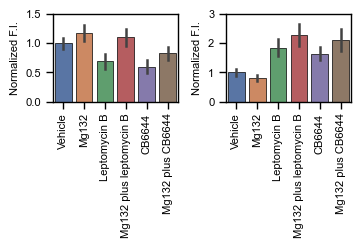

In [183]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (3.7,3))

g = sns.barplot(IntensitiesByWell_HCT116.query('CELL == "HCT116" & DRUG in @drug_order_all'),
                x = 'DRUG', order = drug_order_all,
                y = 'NUCLEUS_IF_647_Intensity_NORMED',
                hue = 'DRUG', hue_order = drug_order_all, dodge = False, palette = 'deep',
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd',
                ax = a[0])
g.legend().remove()

g = sns.barplot(IntensitiesByWell_HCT116.query('CELL == "HCT116" & DRUG in @drug_order_all'),
                x = 'DRUG', order = drug_order_all,
                y = 'CYTOPLASM_IF_647_Intensity_NORMED',
                hue = 'DRUG', hue_order = drug_order_all, dodge = False, palette = 'deep',
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd',
                ax = a[1])
g.legend().remove()



a[0].set_ylim(0,1.5)
a[1].set_ylim(0,3)
a[1].set_yticks([0,1,2,3])

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.7)
    a[i].tick_params(axis='both', labelsize=8)
    a[i].tick_params(axis='x', rotation = 90)

plt.tight_layout()

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/3627993230.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/3627993230.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()


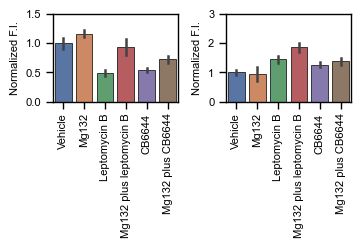

In [184]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (3.7,3))

g = sns.barplot(IntensitiesByWell_mCherryPOLR2A.query('DRUG in @drug_order_all'),
                x = 'DRUG', order = drug_order_all,
                y = 'NUCLEUS_IF_647_Intensity_NORMED',
                hue = 'DRUG', hue_order = drug_order_all, dodge = False, palette = 'deep',
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd',
                ax = a[0])
g.legend().remove()

g = sns.barplot(IntensitiesByWell_mCherryPOLR2A.query('DRUG in @drug_order_all'),
                x = 'DRUG', order = drug_order_all,
                y = 'CYTOPLASM_IF_647_Intensity_NORMED',
                hue = 'DRUG', hue_order = drug_order_all, dodge = False, palette = 'deep',
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd',
                ax = a[1])
g.legend().remove()



a[0].set_ylim(0,1.5)
a[1].set_ylim(0,3)
a[1].set_yticks([0,1,2,3])

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.7)
    a[i].tick_params(axis='both', labelsize=8)
    a[i].tick_params(axis='x', rotation = 90)

plt.tight_layout()

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/2294268415.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/2294268415.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()


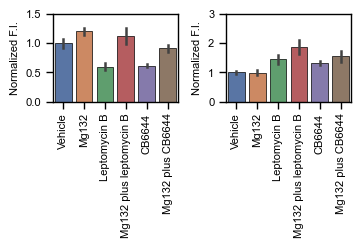

In [185]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (3.7,3))

g = sns.barplot(IntensitiesByWell_mCherryPOLR2A.query('DRUG in @drug_order_all'),
                x = 'DRUG', order = drug_order_all,
                y = 'NUCLEUS_IF_561_Intensity_NORMED',
                hue = 'DRUG', hue_order = drug_order_all, dodge = False, palette = 'deep',
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd',
                ax = a[0])
g.legend().remove()

g = sns.barplot(IntensitiesByWell_mCherryPOLR2A.query('DRUG in @drug_order_all'),
                x = 'DRUG', order = drug_order_all,
                y = 'CYTOPLASM_IF_561_Intensity_NORMED',
                hue = 'DRUG', hue_order = drug_order_all, dodge = False, palette = 'deep',
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd',
                ax = a[1])
g.legend().remove()



a[0].set_ylim(0,1.5)
a[1].set_ylim(0,3)
a[1].set_yticks([0,1,2,3])

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(0.7)
    a[i].tick_params(axis='both', labelsize=8)
    a[i].tick_params(axis='x', rotation = 90)

plt.tight_layout()

## plots for manuscript

In [107]:
pal = sns.color_palette([sns.color_palette('tab20')[15], sns.color_palette('tab20')[17],  sns.color_palette('tab20')[11], sns.color_palette('tab20')[7]])
pal

[(0.7803921568627451, 0.7803921568627451, 0.7803921568627451),
 (0.8588235294117647, 0.8588235294117647, 0.5529411764705883),
 (0.7686274509803922, 0.611764705882353, 0.5803921568627451),
 (1.0, 0.596078431372549, 0.5882352941176471)]

In [108]:
drug_order_plot = ['Vehicle','Mg132','Leptomycin B','Mg132 plus leptomycin B']

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/622907474.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/622907474.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()


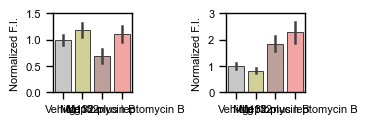

In [114]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (3.7,1.8))

g = sns.barplot(IntensitiesByWell_HCT116.query('CELL == "HCT116" & DRUG in @drug_order_plot'),
                x = 'DRUG', order = drug_order_plot,
                y = 'NUCLEUS_IF_647_Intensity_NORMED',
                hue = 'DRUG', hue_order = drug_order_plot, dodge = False, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd',
                ax = a[0])
g.legend().remove()

g = sns.barplot(IntensitiesByWell_HCT116.query('CELL == "HCT116" & DRUG in @drug_order_plot'),
                x = 'DRUG', order = drug_order_plot,
                y = 'CYTOPLASM_IF_647_Intensity_NORMED',
                hue = 'DRUG', hue_order = drug_order_plot, dodge = False, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd',
                ax = a[1])
g.legend().remove()



a[0].set_ylim(0,1.5)
a[1].set_ylim(0,3)
a[1].set_yticks([0,1,2,3])

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(1)
    a[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()

plt.savefig('HCT116_MG132_LMB_cyto_nuclear.svg')

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/1122618671.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/1122618671.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()


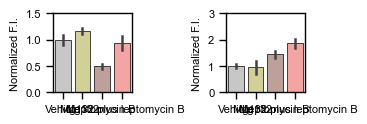

In [188]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (3.7,1.8))

g = sns.barplot(IntensitiesByWell_mCherryPOLR2A.query('DRUG in @drug_order_plot'),
                x = 'DRUG', order = drug_order_plot,
                y = 'NUCLEUS_IF_647_Intensity_NORMED',
                hue = 'DRUG', hue_order = drug_order_plot, dodge = False, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd',
                ax = a[0])
g.legend().remove()

g = sns.barplot(IntensitiesByWell_mCherryPOLR2A.query('DRUG in @drug_order_plot'),
                x = 'DRUG', order = drug_order_plot,
                y = 'CYTOPLASM_IF_647_Intensity_NORMED',
                hue = 'DRUG', hue_order = drug_order_plot, dodge = False, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd',
                ax = a[1])
g.legend().remove()



a[0].set_ylim(0,1.5)
a[1].set_ylim(0,3)
a[1].set_yticks([0,1,2,3])

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(1)
    a[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()

plt.savefig('mCherryPOLR2A_F12_MG132_LMB_cyto_nuclear.svg')

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/2872539745.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()
/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/2872539745.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()


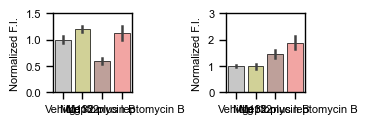

In [189]:
sns.set_context('paper')

f, a = plt.subplots(ncols = 2, figsize = (3.7,1.8))

g = sns.barplot(IntensitiesByWell_mCherryPOLR2A.query('DRUG in @drug_order_plot'),
                x = 'DRUG', order = drug_order_plot,
                y = 'NUCLEUS_IF_561_Intensity_NORMED',
                hue = 'DRUG', hue_order = drug_order_plot, dodge = False, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd',
                ax = a[0])
g.legend().remove()

g = sns.barplot(IntensitiesByWell_mCherryPOLR2A.query('DRUG in @drug_order_plot'),
                x = 'DRUG', order = drug_order_plot,
                y = 'CYTOPLASM_IF_561_Intensity_NORMED',
                hue = 'DRUG', hue_order = drug_order_plot, dodge = False, palette = pal,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd',
                ax = a[1])
g.legend().remove()



a[0].set_ylim(0,1.5)
a[1].set_ylim(0,3)
a[1].set_yticks([0,1,2,3])

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(1)
    a[i].tick_params(axis='both', labelsize=8)

plt.tight_layout()

plt.savefig('mCherryPOLR2A_mCherryIF_MG132_LMB_cyto_nuclear.svg')

## plot for manuscript - CB6644 effect in parental cells

/var/folders/fc/5gv13_yd4dsb1lyy_6mmgkh00000gq/T/ipykernel_1598/1679105030.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  g.legend().remove()


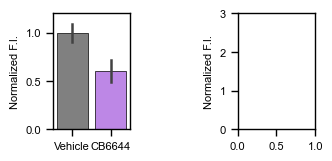

In [192]:
sns.set_context('paper')

cb_plot = ['Vehicle', 'CB6644']
cb_palette = ['grey', 'xkcd:light purple']

f, a = plt.subplots(ncols = 2, figsize = (3.7,1.5), layout = 'constrained')

g = sns.barplot(IntensitiesByWell_HCT116.query('DRUG in @cb_plot'),
              x = 'DRUG', order = cb_plot,
              y = 'NUCLEUS_IF_647_Intensity_NORMED',
              ax = a[0],
              hue = 'DRUG', hue_order = cb_plot, dodge = False, palette = cb_palette,
                edgecolor = 'black', linewidth = 0.5,
                errorbar = 'sd')
g.legend().remove()


a[0].set_ylim(0,1.2)
a[1].set_ylim(0,3)
a[0].set_yticks([0,0.5,1])
a[0].set_xticks([0,1], labels = ['Vehicle','CB6644'])

for i in range(2):
    a[i].set_xlabel('', fontsize = 8)
    a[i].set_ylabel('Normalized F.I.', fontsize = 8)
    a[i].set_box_aspect(1.5)
    a[i].tick_params(axis='both', labelsize=8)

plt.savefig('HCT116_F12_CB6644_8hours.svg')